In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# from module_8 import FlowMatchingModel 
from module_new import FlowMatchingModel
from models_new import ResNetBranch
import random
import Pk_library as PKL
import scienceplots
plt.style.use('science')

def get_pk(mat):
    BoxSize = 25.0    
    MAS     = 'None'  
    threads = 1   
    delta = (mat-mat.mean()) / mat.std()
    pk = PKL.Pk_plane(delta,BoxSize,MAS,threads,verbose=False)
    # print(np.asarray(pk.k).max())
    return pk.k, pk.Pk

def get_xcorr(delta1, delta2):
    BoxSize = 25
    MAS1    = 'None'
    MAS2    = 'None'
    threads = 1
    XPk2D = PKL.XPk_plane(delta1, delta2, BoxSize, MAS1, MAS2, threads)
    return XPk2D.k, XPk2D.XPk / np.sqrt(XPk2D.Pk[:,0] * XPk2D.Pk[:,1])

In [2]:
def load_model(checkpoint_path, device=None):
    """Load trained flow matching model from checkpoint"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = FlowMatchingModel.load_from_checkpoint(checkpoint_path, map_location=device)
    model.to(device)
    model.eval()
    return model, device

In [11]:
# Even simpler version that just returns predictions vs truth
def sampling(checkpoint_path, idx_sim,
             cdm_mass_path_sim, star_maps_path_sim, gas_maps_path_sim, 
             T_maps_path_sim, P_maps_path_sim, params_path_sim,
             num_steps=50):

    # Load model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
    model.to(device)
    model.eval()

    # Load data
    cdm_mass_maps = np.load(cdm_mass_path_sim)
    star_maps = np.load(star_maps_path_sim)
    gas_maps = np.load(gas_maps_path_sim)
    T_maps = np.load(T_maps_path_sim)
    P_maps = np.load(P_maps_path_sim)
    params = np.loadtxt(params_path_sim)

    # Normalize
    sample_tot = np.log1p(cdm_mass_maps[idx_sim])
    tot_mean, tot_std = np.log1p(cdm_mass_maps).mean(), np.log1p(cdm_mass_maps).std()
    sample_tot_norm = (sample_tot - tot_mean) / tot_std
    
    # Add noise
    noisy_tot = sample_tot_norm + np.random.normal(loc=0, scale=0.2, size=(256, 256))
    
    # Truth maps
    star_map_norm = (np.log1p(star_maps[idx_sim]) - np.log1p(star_maps[idx_sim]).mean()) / np.log1p(star_maps[idx_sim]).std()
    gas_map_norm = (np.log1p(gas_maps[idx_sim]) - np.log1p(gas_maps[idx_sim]).mean()) / np.log1p(gas_maps[idx_sim]).std()
    T_map_norm = (np.log1p(T_maps[idx_sim]) - np.log1p(T_maps[idx_sim]).mean()) / np.log1p(T_maps[idx_sim]).std()
    P_map_norm = (np.log1p(P_maps[idx_sim]) - np.log1p(P_maps[idx_sim]).mean()) / np.log1p(P_maps[idx_sim]).std()
    
    # ResNet input
    truth_maps = np.stack([star_map_norm, gas_map_norm, T_map_norm, P_map_norm], axis=0)
    resnet_input_tensor = torch.tensor(truth_maps, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Prepare tensors
    cdm_mass_tensor = torch.tensor(noisy_tot, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    cond_tensor = torch.tensor(sample_tot_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    astro_params = params[idx_sim//15, :2]
    params_tensor = torch.tensor(astro_params, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Generate prediction
    with torch.no_grad():
        pred = model.sample(
            cdm_mass=cdm_mass_tensor,
            astro_params=params_tensor,
            cdm_mass_condition=cond_tensor,
            resnet_input=resnet_input_tensor,
            resnet_embed=None,
            num_steps=num_steps,
            method='euler'
        ).cpu().numpy()[0]
    
    return {
        'prediction': pred,  # Shape: (4, 256, 256)
        'truth': {
            'star': star_map_norm,
            'gas': gas_map_norm,
            'T': T_map_norm,
            'P': P_map_norm
        },
        'input': {
            'cdm_mass': noisy_tot,
            'astro_params': astro_params
        }
    }

In [19]:
output = sampling(
    checkpoint_path='/n/netscratch/iaifi_lab/Lab/msliu/FM_4channel/lightning_logs/simba_only/checkpoints/best-model-epoch=156-val_loss=0.029530.ckpt',
    idx_sim=10,
    # SIMBA dataset paths
    cdm_mass_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mcdm_SIMBA_CV_z=0.00.npy',
    star_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mstar_SIMBA_CV_z=0.00.npy',
    gas_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mgas_SIMBA_CV_z=0.00.npy',
    T_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_T_SIMBA_CV_z=0.00.npy',
    P_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_P_SIMBA_CV_z=0.00.npy',
    params_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/params_CV_SIMBA.txt',
    num_steps=1000
)

output_with_other_sims = sampling(
    checkpoint_path='/n/netscratch/iaifi_lab/Lab/msliu/FM_4channel/lightning_logs/new/checkpoints/best-model-epoch=92-val_loss=0.035356.ckpt',
    idx_sim=10,
    # SIMBA dataset paths
    cdm_mass_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mcdm_SIMBA_CV_z=0.00.npy',
    star_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mstar_SIMBA_CV_z=0.00.npy',
    gas_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mgas_SIMBA_CV_z=0.00.npy',
    T_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_T_SIMBA_CV_z=0.00.npy',
    P_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_P_SIMBA_CV_z=0.00.npy',
    params_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/params_CV_SIMBA.txt',
    num_steps=1000
)

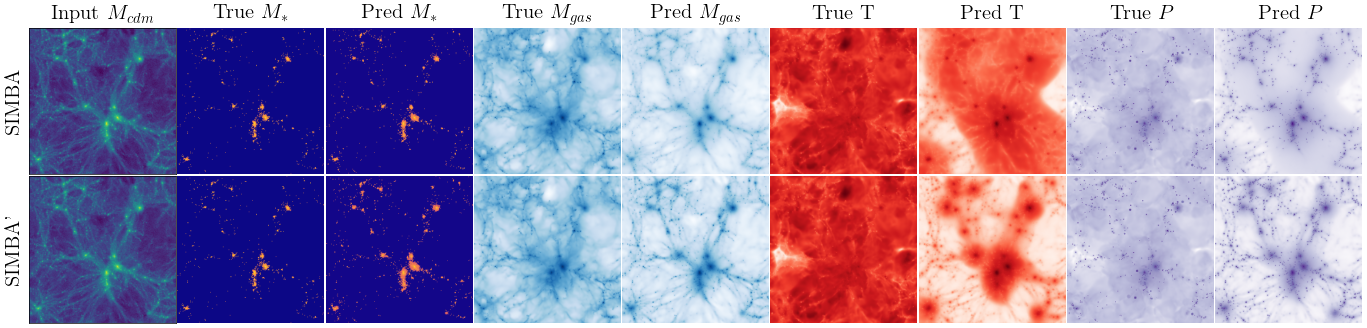

In [22]:

fig, axes = plt.subplots(2, 9, figsize=(17.2, 3.86))
fig.subplots_adjust(wspace=0.00, hspace=0.00)

# Extract data from result
prediction = output['prediction']  # Shape: (4, 256, 256)
truth = output['truth']
input_data = output['input']
prediction_other = output_with_other_sims['prediction']  # Shape: (4, 256, 256)
truth_other = output_with_other_sims['truth']
input_data_other = output_with_other_sims['input']

# Channel configuration: (truth_data, cmap, label)
channels = [
    (truth['star'], prediction[0], 'plasma', '$M_*$'),
    (truth['gas'], prediction[1], 'Blues', '$M_{gas}$'),
    (truth['T'], prediction[2], 'Reds', 'T'),
    (truth['P'], prediction[3], 'Purples', '$P$')
]

channels_other = [
    (truth_other['star'], prediction_other[0], 'plasma', '$M_*$'),
    (truth_other['gas'], prediction_other[1], 'Blues', '$M_{gas}$'),
    (truth_other['T'], prediction_other[2], 'Reds', 'T'),
    (truth_other['P'], prediction_other[3], 'Purples', '$P$')
]

# Column 0: Input CDM map for both rows
axes[0, 0].imshow(input_data['cdm_mass'], cmap='viridis')
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])
axes[0, 0].set_title('Input $M_{cdm}$', fontsize=15)
axes[0, 0].set_ylabel("SIMBA", fontsize=15)

axes[1, 0].imshow(input_data_other['cdm_mass'], cmap='viridis')
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])
# Don't repeat title for second row
axes[1, 0].set_ylabel("SIMBA'", fontsize=15)

# Columns 1-8: Channel pairs (true, pred) for first row
for ch_idx, (true_data, pred_data, cmap, label) in enumerate(channels):
    col_true = 1 + ch_idx * 2
    col_pred = col_true + 1
    
    # First row - True channel
    axes[0, col_true].imshow(true_data, cmap=cmap)
    axes[0, col_true].axis('off')
    axes[0, col_true].set_title(f'True {label}', fontsize=15)
    
    # First row - Predicted channel
    axes[0, col_pred].imshow(pred_data, cmap=cmap)
    axes[0, col_pred].axis('off')
    axes[0, col_pred].set_title(f'Pred {label}', fontsize=15)

# Columns 1-8: Channel pairs (true, pred) for second row
for ch_idx, (true_data_other, pred_data_other, cmap, label) in enumerate(channels_other):
    col_true = 1 + ch_idx * 2
    col_pred = col_true + 1
    
    # Second row - True channel
    axes[1, col_true].imshow(true_data_other, cmap=cmap)
    axes[1, col_true].axis('off')
    # Don't repeat titles for second row
    
    # Second row - Predicted channel
    axes[1, col_pred].imshow(pred_data_other, cmap=cmap)
    axes[1, col_pred].axis('off')
    # Don't repeat titles for second row

plt.subplots_adjust(wspace=0.01)
plt.savefig('simba_only.png')
plt.show()